<a href="https://colab.research.google.com/github/stefanogiagu/corso_AML_2026/blob/main/notebooks/AML_2026_E3_KnowledgeDistillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Machine Learning for Physics 2026

## Hands-on session 3: Knowledge Distillation with DNNs


**Scope:** distill knowledge from a larger teached DNN to a smaller student network for a classification task

**Tasks:** <p>

1.   download and preprocess the GalaxyZoo2 simplified dataset
2.   implement a teacher and a student model and train it individually, the student with a smaller subset of the training data
3.   train the student via knowledge distillation from the teacherm and check improvement in perfromance


**V1.0 - 29.3.2026** - Stefano Giagu <stefano.giagu@uniroma1.it>

*   [slides](https://github.com/stefanogiagu/corso_AML_2026/blob/main/notebooks/AML_2026_E3_KnowledgeDistillation.pdf)

The notebook implements **logits-based knowledge distillation (KD)** for a **Convolutional Neural Network (CNN)** classification task (identification of type of galaxy from galaxy pictures).

We compress a trained **teacher (master)** CNN into a smaller **student** CNN (same architecture, less deep and wide, trained with a smaller subset of the data, by training the student with a combination of:

- **Cross-Entropy (CE)** loss on the ground-truth labels, and
- **KL-divergence** between teacher and student softened class distributions (logits distillation).

### Dataset

[Resized and Reduced Galaxy Zoo 2 Images](https://arxiv.org/abs/1711.05744), made by ~$120000$ training and ~$13000$ test jpg images with shape $(3,69,69)$.

Each image belong to one of three broad galacy type classes:

1.   **E**: elliptical shaped galaxies
2.   **S**: normal spiral shaped galaxies
3.   **SB**: barred spiral shaped galaxies


### Objectives

- define a **teacher** CNN and a **smaller student** architecture
- train the teacher with a large chunk of data, and the student with a much smaller one, and compare performance
- train again the teacher using logits distillation and compare performance. The student objective will be the standard KD objective:
  
  $$
  L_{kd} = \text{CrossEntropyLoss}(y, s) + \alpha\,T^2\text{KL}\big[\text{softmax}\big(\frac{t}{T}\big)\;\|\;\text{softmax}\big(\frac{s}{T}\big)\big]
  $$
  
  where:
  - $t$ are the teacher logits,
  - $s$ are the student logits,
  - $T$ is the temperature,
  - $\alpha$ balances ground-truth supervision vs distillation.

### Experimental Setup

- **Teacher**: 6 CNN 2D layers with ~1M parameters
- **Student**: 3 CNN 2D layers with ~10k parameters
- **Data usage**: student is trained on a subset of the **same training split** used for teacher training



In [3]:
# download the dataset (reduced/simplified version of GalaxyZoo2)

!rm -rf images_E_S_SB_69x69_a_03
!rm -rf images_E_S_SB_69x69_a_03.zip
!wget http://giagu.web.cern.ch/giagu/CERN/images_E_S_SB_69x69_a_03.zip
!unzip -q images_E_S_SB_69x69_a_03.zip

--2026-03-29 10:59:39--  http://giagu.web.cern.ch/giagu/CERN/images_E_S_SB_69x69_a_03.zip
Resolving giagu.web.cern.ch (giagu.web.cern.ch)... 188.185.5.88, 188.185.50.104, 137.138.55.232, ...
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|188.185.5.88|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://giagu.web.cern.ch/giagu/CERN/images_E_S_SB_69x69_a_03.zip [following]
--2026-03-29 10:59:40--  https://giagu.web.cern.ch/giagu/CERN/images_E_S_SB_69x69_a_03.zip
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|188.185.5.88|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 176369943 (168M) [application/zip]
Saving to: ‘images_E_S_SB_69x69_a_03.zip’

images_E_S_SB_69x69 100%[===================>] 168.20M  19.2MB/s    in 10s     

2026-03-29 10:59:51 (16.6 MB/s) - ‘images_E_S_SB_69x69_a_03.zip’ saved [176369943/176369943]



In [4]:
# read data and create datasets and dataloaders

import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# Define the transformations for the images (jpg -> torch tensor)
# Note: transforms.ToTensor() automatically normalizes pixel values from [0, 255] to [0.0, 1.0]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Define paths
base_dir = 'images_E_S_SB_69x69_a_03'
train_dir = os.path.join(base_dir, 'images_E_S_SB_69x69_a_03_train')
test_dir = os.path.join(base_dir, 'images_E_S_SB_69x69_a_03_test')

# full training dataset
full_train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
categories = full_train_dataset.classes

# select two subsamples to limit the dataset size (to speedup the exercise)
num_train_samples_teacher = 30000
num_train_samples_student = 5000

# split training dataset into two subsamples

if num_train_samples_teacher is not None and num_train_samples_teacher < len(full_train_dataset):
    train_dataset_teacher, _ = random_split(full_train_dataset, [num_train_samples_teacher, len(full_train_dataset) - num_train_samples_teacher])
else:
    train_dataset_teacher = full_train_dataset

if num_train_samples_student is not None and num_train_samples_student < len(full_train_dataset):
    train_dataset_student, _ = random_split(full_train_dataset, [num_train_samples_student, len(full_train_dataset) - num_train_samples_student])
else:
    train_dataset_student = full_train_dataset


# validation and test dataset (load full test subdir and then split it)
full_test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=transform)

# split 50% for validation and 50% for testing
test_size = len(full_test_dataset) // 2
val_size = len(full_test_dataset) - test_size
val_dataset, test_dataset = random_split(full_test_dataset, [val_size, test_size])

# dataloaders
batch_size = 32

train_loader_teacher = DataLoader(train_dataset_teacher, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
train_loader_student = DataLoader(train_dataset_student, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print('Training teacher dataset size: ',len(train_dataset_teacher))
print('Training student dataset size: ',len(train_dataset_student))
print('Validation dataset size: ',len(val_dataset))
print('Test dataset size: ',len(test_dataset))
print('Categories: ', categories)

Training teacher dataset size:  30000
Training student dataset size:  5000
Validation dataset size:  6690
Test dataset size:  6690
Categories:  ['E', 'S', 'SB']


In [5]:
# define CNNs (two VGG like CNNs, one deeper (Teacher) and one lighter (Student))

import torch.nn as nn

# Teacher CNN
class Teacher(nn.Module):
    def __init__(self, num_classes=3):
        super(Teacher, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Student CNN
class Student(nn.Module):
    def __init__(self, num_classes=3):
        super(Student, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(4, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(4, 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [6]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using',device, 'device')

Using cuda device


In [7]:
# print models structure

teacher = Teacher().to(device)
student = Student().to(device)

print(teacher)

from torchsummary import summary
if torch.cuda.is_available():
  summary(teacher.cuda(), input_size=(3,69,69))
else:
  summary(teacher, input_size=(3,69,69))

print(student)
if torch.cuda.is_available():
  summary(student.cuda(), input_size=(3,69,69))
else:
  summary(student, input_size=(3,69,69))

Teacher(
  (features): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Li

In [9]:
# test the untrained models on the first batch of the train dataloader

teacher = Teacher().to(device)
student = Student().to(device)

xa, ya = next(iter(train_loader_teacher))
xa, ya = xa.to(device), ya.to(device)

with torch.no_grad():
  teacher_out = teacher(xa)
  student_out = student(xa)
  print('Teacher output shape: ', teacher_out.shape)
  print('Student output shape: ', student_out.shape)

  print('Teacher output argmax: ', torch.argmax(teacher_out, dim=1))
  print('Student output argmax: ', torch.argmax(student_out, dim=1))

Teacher output shape:  torch.Size([32, 3])
Student output shape:  torch.Size([32, 3])
Teacher output argmax:  tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')
Student output argmax:  tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


In [10]:
# install torchmetrics

!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.1 MB/s eta 0:00:00


In [11]:
# define optimizer, loss and accuracy

# instantiate both models

teacher = Teacher().to(device)
student = Student().to(device)

import torch.optim as optim

criterion = nn.CrossEntropyLoss()

teacher_optimizer = optim.Adam(teacher.parameters(), lr=0.001)
student_optimizer = optim.Adam(student.parameters(), lr=0.001)

# learning rate schedulers (StepLR decays the lr by gamma every step_size epochs)
teacher_scheduler = optim.lr_scheduler.StepLR(teacher_optimizer, step_size=10, gamma=0.5)
student_scheduler = optim.lr_scheduler.StepLR(student_optimizer, step_size=10, gamma=0.5)

from torchmetrics import Accuracy
teacher_accuracy = Accuracy(task="multiclass", num_classes=3).to(device)
student_accuracy = Accuracy(task="multiclass", num_classes=3).to(device)

In [12]:
# Training loop

import time
import torch

def train_and_validate(model, train_loader, val_loader, optimizer, criterion, metric, device, epochs=10, save_path='best_model.pth', debug=False, scheduler=None):
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        t0 = time.time()
        # training step
        model.train()
        running_train_loss = 0.0
        metric.reset()

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            if (i == 0 and debug == True):
                # test the first event at each epoch
                # predicted class by finding the index with the max logit/probability
                predicted_label = torch.argmax(outputs[0]).item()
                true_label = labels[0].item()
                print(f"Epoch {epoch+1} | First event - Predicted Label: {predicted_label}, True Label: {true_label}")

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)
            metric.update(outputs, labels)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_metric = metric.compute().item()
        train_losses.append(epoch_train_loss)
        train_metrics.append(epoch_train_metric)

        # validation step
        model.eval()
        running_val_loss = 0.0
        metric.reset()

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                metric.update(outputs, labels)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_metric = metric.compute().item()
        val_losses.append(epoch_val_loss)
        val_metrics.append(epoch_val_metric)

        # Checkpoint to save the best model
        if epoch_val_loss < best_val_loss:
            print('Validation loss decreased ',best_val_loss, '--> ',epoch_val_loss,' Saving model to ', save_path)
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)

        # Step the scheduler if one is provided
        if scheduler is not None:
            scheduler.step()

        elapsed_time = time.time()-t0
        print(f"Epoch {epoch+1}/{epochs} | time {elapsed_time:.4f} | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_metric:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_metric:.4f}\n")

    return train_losses, val_losses, train_metrics, val_metrics

In [13]:
# train both models

epochs_t = 15
epochs_s = 30
# train teacher
print('Training Teacher...')
torch.manual_seed(1234)
teacher_train_losses, teacher_val_losses, teacher_train_metrics, teacher_val_metrics = train_and_validate(
    teacher, train_loader_teacher, val_loader, teacher_optimizer, criterion, teacher_accuracy, device, epochs=epochs_t, save_path='best_teacher.pth', debug=False, scheduler=teacher_scheduler
)

# train student
print('\nTraining Student...')
torch.manual_seed(1234)
student_train_losses, student_val_losses, student_train_metrics, student_val_metrics = train_and_validate(
    student, train_loader_student, val_loader, student_optimizer, criterion, student_accuracy, device, epochs=epochs_s, save_path='best_student.pth', debug=False, scheduler=student_scheduler
)

Training Teacher...
Validation loss decreased  inf -->  0.7136147064656598  Saving model to  best_teacher.pth
Epoch 1/15 | time 28.3353 | Train Loss: 0.7213, Train Acc: 0.7091 | Val Loss: 0.7136, Val Acc: 0.7286

Validation loss decreased  0.7136147064656598 -->  0.6315824129745387  Saving model to  best_teacher.pth
Epoch 2/15 | time 28.1189 | Train Loss: 0.6585, Train Acc: 0.7442 | Val Loss: 0.6316, Val Acc: 0.7610

Epoch 3/15 | time 28.0660 | Train Loss: 0.6287, Train Acc: 0.7593 | Val Loss: 0.6462, Val Acc: 0.7549

Validation loss decreased  0.6315824129745387 -->  0.610451586346277  Saving model to  best_teacher.pth
Epoch 4/15 | time 28.5098 | Train Loss: 0.6003, Train Acc: 0.7662 | Val Loss: 0.6105, Val Acc: 0.7682

Validation loss decreased  0.610451586346277 -->  0.5571474102491398  Saving model to  best_teacher.pth
Epoch 5/15 | time 28.9301 | Train Loss: 0.5742, Train Acc: 0.7775 | Val Loss: 0.5571, Val Acc: 0.7755

Validation loss decreased  0.5571474102491398 -->  0.533805907

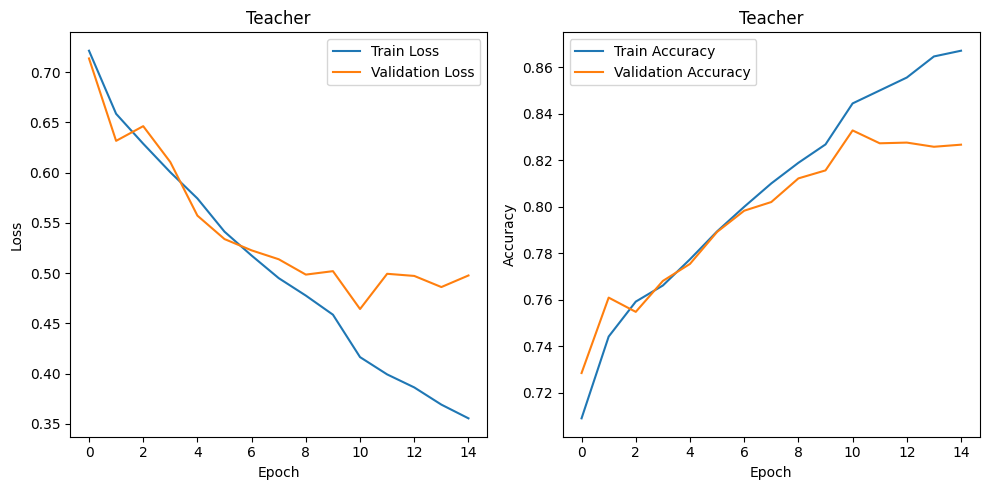

In [14]:
# training plots for teacher

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2,1)
plt.plot(teacher_train_losses, label='Train Loss')
plt.plot(teacher_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Teacher')

plt.subplot(1, 2,2)
plt.plot(teacher_train_metrics, label='Train Accuracy')
plt.plot(teacher_val_metrics, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Teacher')

plt.tight_layout()
plt.show()

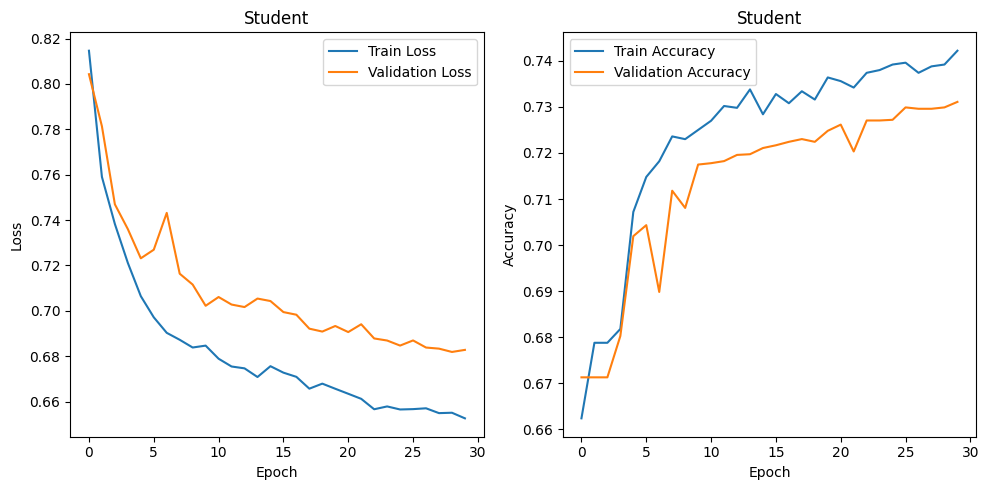

In [15]:
# training plots for student

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2,1)
plt.plot(student_train_losses, label='Train Loss')
plt.plot(student_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Student')

plt.subplot(1, 2,2)
plt.plot(student_train_metrics, label='Train Accuracy')
plt.plot(student_val_metrics, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Student')

plt.tight_layout()
plt.show()

In [16]:
# evaluate performance of the best models on the test set

teacher = Teacher().to(device)
student = Student().to(device)

teacher.load_state_dict(torch.load('best_teacher.pth'))
student.load_state_dict(torch.load('best_student.pth'))

teacher.eval()
student.eval()

test_accuracy_t = Accuracy(task="multiclass", num_classes=3).to(device)
test_accuracy_s = Accuracy(task="multiclass", num_classes=3).to(device)

with torch.no_grad():
  #loop
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    teacher_outputs = teacher(inputs)
    student_outputs = student(inputs)
    test_accuracy_t(teacher_outputs, labels)
    test_accuracy_s(student_outputs, labels)

print('Teacher test accuracy: ', test_accuracy_t.compute().item())
print('Student test accuracy: ', test_accuracy_s.compute().item())

Teacher test accuracy:  0.835724949836731
Student test accuracy:  0.7375186681747437


In [30]:
# Teacher Dark Knowledge

import torch.nn.functional as F

teacher.eval()
torch.manual_seed(1234)
# take a batch from validation
inputs, labels = next(iter(test_loader))
inputs = inputs.to(device)

with torch.no_grad():
    logits = teacher(inputs)

# standard probabilities (T = 1)
probs_T1 = F.softmax(logits, dim=1)

# soft probabilities (T = 5 for example)
T = 5.0
probs_T5 = F.softmax(logits / T, dim=1)

# print one example
idx = 0
print("True label:", labels[idx].item())

print("\nTop-2 probabilities (T=1):")
topk = torch.topk(probs_T1[idx], 2)
for i in range(2):
    print(f"Class {topk.indices[i].item()}: {topk.values[i].item():.4f}")

print("\nTop-2 probabilities (T=5):")
topk = torch.topk(probs_T5[idx], 2)
for i in range(2):
    print(f"Class {topk.indices[i].item()}: {topk.values[i].item():.4f}")


# note that with T=1 the results are almost one-hot, so there is little information, with T-5 instead there is a reacher structure
# (dark knowledgeL this example look not as only class 2, but looks a bit of class 2 and a bit of class 1)

True label: 0

Top-2 probabilities (T=1):
Class 0: 0.8999
Class 1: 0.0834

Top-2 probabilities (T=5):
Class 0: 0.4827
Class 1: 0.3000


In [31]:
# student training with Knowledge Distillation

# instantiate the student model
student_kd = Student().to(device)

# Loss (1-alpha)*x-entropy(student_logits, y) + alpha * loss_kd(teacher_logits, student_logits)

criterion = nn.CrossEntropyLoss()

import torch.nn.functional as F

def loss_kd(student_logits, teacher_logits, T=2.0):
  # soften the student logits by applying softmax first and log() second
  p_teacher = F.softmax(teacher_logits / T, dim=1)
  log_p_student = F.log_softmax(student_logits / T, dim=1)
  distill = F.kl_div(log_p_student, p_teacher, reduction="batchmean") * (T * T)
  #note the T^2 normalization (when we introduce temperature T, we scale down the gradients by T**2, so by multipling with T**2 we restore the correct gradient magnitude)
  return distill


student_kd_optimizer = optim.Adam(student_kd.parameters(), lr=0.001)
student_kd_scheduler = optim.lr_scheduler.StepLR(student_kd_optimizer, step_size=10, gamma=0.5)


from torchmetrics import Accuracy
student_kd_accuracy = Accuracy(task="multiclass", num_classes=3).to(device)

In [32]:
import time
import torch

def train_and_validate_kd(model_t, model, train_loader, val_loader, optimizer, criterion, criterion_s, metric, device, epochs=10, save_path='best_model.pth', debug=False, scheduler=None, alpha=0.5, T=2.0):
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        t0 = time.time()
        # training step

        model_t.eval()
        model.train()
        running_train_loss = 0.0
        metric.reset()

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Teacher logits (frozen)
            with torch.no_grad():
              t_logits = model_t(inputs)

            optimizer.zero_grad()
            outputs = model(inputs)

            if (i == 0 and debug == True):
                # test the first event at each epoch
                # predicted class by finding the index with the max logit/probability
                predicted_label = torch.argmax(outputs[0]).item()
                true_label = labels[0].item()
                print(f"Epoch {epoch+1} | First event - Predicted Label: {predicted_label}, True Label: {true_label}")


            # loss = x-entropy(student_logits, y) + alpha * loss_kd(teacher_logits, student_logits)
            loss = (1-alpha)*criterion(outputs, labels) + alpha * criterion_s(outputs, t_logits, T=T)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)
            metric.update(outputs, labels)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_metric = metric.compute().item()
        train_losses.append(epoch_train_loss)
        train_metrics.append(epoch_train_metric)

        # validation step
        model.eval()
        running_val_loss = 0.0
        metric.reset()

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                metric.update(outputs, labels)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_metric = metric.compute().item()
        val_losses.append(epoch_val_loss)
        val_metrics.append(epoch_val_metric)

        # Checkpoint to save the best model
        if epoch_val_loss < best_val_loss:
            print('Validation loss decreased ',best_val_loss, '--> ',epoch_val_loss,' Saving model to ', save_path)
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)

        # Step the scheduler if one is provided
        if scheduler is not None:
            scheduler.step()

        elapsed_time = time.time()-t0
        print(f"Epoch {epoch+1}/{epochs} | time {elapsed_time:.4f} | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_metric:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_metric:.4f}\n")

    return train_losses, val_losses, train_metrics, val_metrics

In [33]:
epochs_kd = 30

print('Training Student with KD ...')
torch.manual_seed(1234)
student_kd_train_losses, student_kd_val_losses, student_kd_train_metrics, student_kd_val_metrics = train_and_validate_kd(
    teacher, student_kd, train_loader_student, val_loader, student_kd_optimizer, criterion, loss_kd, student_kd_accuracy, device, epochs=epochs_kd, save_path='best_student_kd.pth', debug=False, scheduler=student_kd_scheduler, alpha=0.5, T=2.0
)

Training Student with KD ...
Validation loss decreased  inf -->  0.8608681524102819  Saving model to  best_student_kd.pth
Epoch 1/30 | time 6.0206 | Train Loss: 0.8690, Train Acc: 0.6492 | Val Loss: 0.8609, Val Acc: 0.6713

Validation loss decreased  0.8608681524102819 -->  0.8045756383505281  Saving model to  best_student_kd.pth
Epoch 2/30 | time 4.9276 | Train Loss: 0.7829, Train Acc: 0.6788 | Val Loss: 0.8046, Val Acc: 0.6713

Validation loss decreased  0.8045756383505281 -->  0.7336579032008423  Saving model to  best_student_kd.pth
Epoch 3/30 | time 6.1236 | Train Loss: 0.7415, Train Acc: 0.6788 | Val Loss: 0.7337, Val Acc: 0.6723

Validation loss decreased  0.7336579032008423 -->  0.7085353364680737  Saving model to  best_student_kd.pth
Epoch 4/30 | time 4.7962 | Train Loss: 0.6768, Train Acc: 0.6984 | Val Loss: 0.7085, Val Acc: 0.7206

Validation loss decreased  0.7085353364680737 -->  0.6965402771895598  Saving model to  best_student_kd.pth
Epoch 5/30 | time 5.8236 | Train Loss:

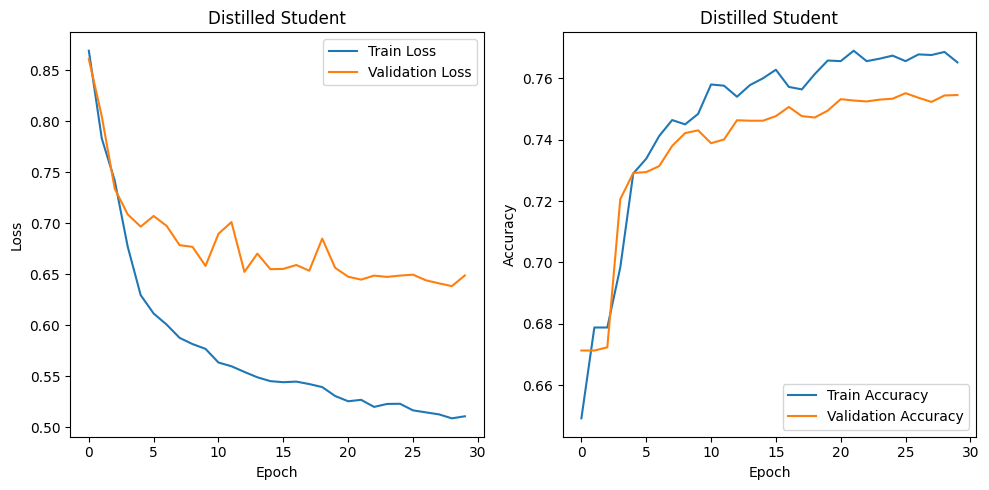

In [34]:
# training plots for KD student

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2,1)
plt.plot(student_kd_train_losses, label='Train Loss')
plt.plot(student_kd_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Distilled Student')

plt.subplot(1, 2,2)
plt.plot(student_kd_train_metrics, label='Train Accuracy')
plt.plot(student_kd_val_metrics, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Distilled Student')

plt.tight_layout()
plt.show()

In [35]:
# evaluate performance of the best models on the test set

teacher = Teacher().to(device)
student = Student().to(device)
student_kd = Student().to(device)

teacher.load_state_dict(torch.load('best_teacher.pth'))
student.load_state_dict(torch.load('best_student.pth'))
student_kd.load_state_dict(torch.load('best_student_kd.pth'))

teacher.eval()
student.eval()
student_kd.eval()

test_accuracy_t = Accuracy(task="multiclass", num_classes=3).to(device)
test_accuracy_s = Accuracy(task="multiclass", num_classes=3).to(device)
test_accuracy_kd = Accuracy(task="multiclass", num_classes=3).to(device)

with torch.no_grad():
  #loop
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    teacher_outputs = teacher(inputs)
    student_outputs = student(inputs)
    student_kd_outputs = student_kd(inputs)
    test_accuracy_t(teacher_outputs, labels)
    test_accuracy_s(student_outputs, labels)
    test_accuracy_kd(student_kd_outputs, labels)

print('Teacher test accuracy: ', test_accuracy_t.compute().item())
print('Student test accuracy: ', test_accuracy_s.compute().item())
print('Distiled Student test accuracy: ', test_accuracy_kd.compute().item())

Teacher test accuracy:  0.835724949836731
Student test accuracy:  0.7375186681747437
Distiled Student test accuracy:  0.7618834376335144


## **Exercises**


*  **Effect of temperature:** vary T and check what happens to soft labels. When does KD imporve performance?
*   **Effect of alpha:** test different values of alpha [0.1,0.5,0.9] and check effects
*   **Data efficiency:** reduce further student training dataset and veryfy that KD helps more with less data
*   (**at home) apply KD with noisy labels and/or class imbalance**. Does it helps in stabilizing training?

